# CoperniFUS in interactive mode
For direct interaction with the data created and manipulated by CoperniFUS

## Step 1. Install CoperniFUS

1. Create a python environment to prevent package version conflicts. Although `pyenv` can be used, [miniconda](https://docs.anaconda.com/miniconda/install/) is recommanded.
    
    `conda create -n coperniFUS_env python=3.12`
2. Make sure that your ipython notebook kernel runs in the `coperniFUS_env` environment.
3. Install CoperniFUS

In [ ]:
!pip install git+https://github.com/Tomaubier/CoperniFUS.git@0.1.2

## Step 2. Launch CoperniFUS
(First launch after install might take some time)

### Specify path where to search for assets.
Assets (such as `.stl` mesh files) loaded by armatures need to be located in a single directory. By default, data will be loaded from `coperniFUS/examples/assets` however this behaviour can be changed by providing an `assets_dir_path` argument.

In [1]:
from coperniFUS.viewer import coperniFUSviewer
from coperniFUS import *

cfv = coperniFUSviewer() # Optional: Provide assets_dir_path='path/to/your/armature/assets'

Launching CoperniFUS v0.1.0

> Info: Like any text outputs, warnings and error messages will be outputed to the internal console, to change this behaviour, feel free to set disable_internal_console to True.

> Info: Referencing assets located in /Users/tomaubier/Documents/US_Neurostim/Analysis_scripts/CoperniFUS/coperniFUS/examples/assets directory.

> Info: Cached configuration file location: /Users/tomaubier/coperniFUSCache/Untitled Configuration.json


> For the sake of this interactive demo, load the example configuration described [in the tutorial](https://copernifus.readthedocs.io/en/latest/contents/tutorial.html).

In [ ]:
cfv.load_example_configuration('Dual arms FUS + rec electrode rat tutorial config')

In [3]:
# Modules objects can be grabbed using
cfv.get_module_object_from_name()

# Armatures objects can be grabbed using
stereotaxic_frame_handle = cfv.get_module_object_from_name('StereotaxicFrame')
stereotaxic_frame_handle.armatures_objects

{'Bregma to Stereotaxic Frame Origin': <coperniFUS.modules.armatures.base_armature.Armature at 0x337cb74a0>,
 'Skull Mesh': <coperniFUS.modules.armatures.mesh_armatures.STLMeshArmature at 0x337cb7890>,
 'Brain Mesh': <coperniFUS.modules.armatures.mesh_armatures.STLMeshConvexHull at 0x337cb69c0>,
 'Coordinates Registration Probe Arm': <coperniFUS.modules.armatures.base_armature.Armature at 0x337ccb6e0>,
 'Coords Registration Probe Shaft': <coperniFUS.modules.armatures.base_armature.Armature at 0x337ccb620>,
 'Coords Registration Probe Tip': <coperniFUS.modules.armatures.base_armature.Armature at 0x337ccb5f0>,
 'FUS Transducer Arm': <coperniFUS.modules.armatures.base_armature.Armature at 0x337ccb590>,
 'FUS Transducer Shaft': <coperniFUS.modules.armatures.base_armature.Armature at 0x337ccb530>,
 'FUS Transducer Holder Mesh': <coperniFUS.modules.armatures.mesh_armatures.STLMeshArmature at 0x337ccb4d0>,
 'Theoretical FUS focal spot preview': <coperniFUS.modules.armatures.mesh_armatures.Tri

## Step 3. Running acoustic simulations
1. Compute Brain Mesh (defined as the convex hull of the skull mesh)
2. Compute the acoustic domain (apply boolean operation)
3. Run the k-Wave 3D simulation

![video_export_LUT_editor_screenshot.png](../../docs/_static/tutorial_assets/tuto_32.png)

## Step 4. Grab mesh & pressure simulation data

In [4]:
acsim_armature = cfv.stereotaxic_frame.armatures_objects['kWave 3D Simulation']
acsim_armature

In [5]:
acsim_armature.mesh_handler.stl_item_mesh[1].show()

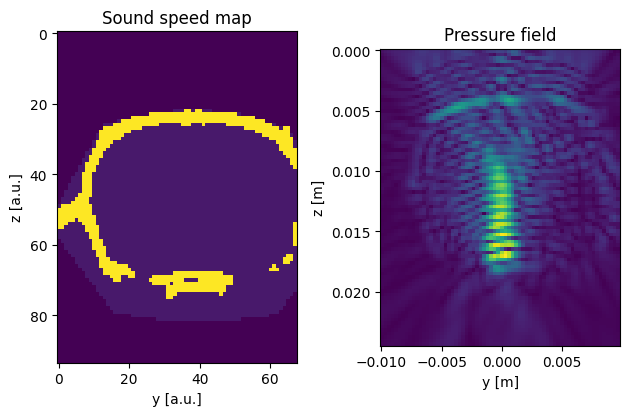

In [6]:
import matplotlib.pyplot as plt

p_amp_xyz, x, y, z = acsim_armature.kw3D.p_amp_xyz

fig, axs = plt.subplots(ncols=2)
axs[0].imshow(acsim_armature.kw3D.medium.sound_speed[34].T)
axs[0].set_title('Sound speed map')
axs[0].set_xlabel('y [a.u.]')
axs[0].set_ylabel('z [a.u.]')

axs[1].imshow(p_amp_xyz[34].T, extent=[y[0], y[-1], z[-1], z[0]])
axs[1].set_title('Pressure field')
axs[1].set_xlabel('y [m]')
axs[1].set_ylabel('z [m]')

plt.tight_layout()
plt.show()

In [7]:
# Grab kWave 3S Simulation Armature affine transform matrix

np.set_printoptions(formatter={'float':lambda x: f'{x:.3e}'})
acsim_armature.end_transform_mat

array([[-9.944e-01, -1.045e-01, -1.745e-02, 0.000e+00],
       [-1.045e-01, 9.945e-01, 1.224e-16, 0.000e+00],
       [1.736e-02, 1.824e-03, -9.998e-01, 0.000e+00],
       [-5.428e-03, -1.251e-03, 3.679e-03, 1.000e+00]])